<a href="https://colab.research.google.com/github/TejashwiniByrappa/Tejashwini-landing-page/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading local dataset from /content/churn.csv...
Successfully loaded data with 7043 rows and 10 columns.

Cleaning and preprocessing data...
Using 'OnlineSecurity' as the target variable for predictions.

Generating Correlation Heatmap...


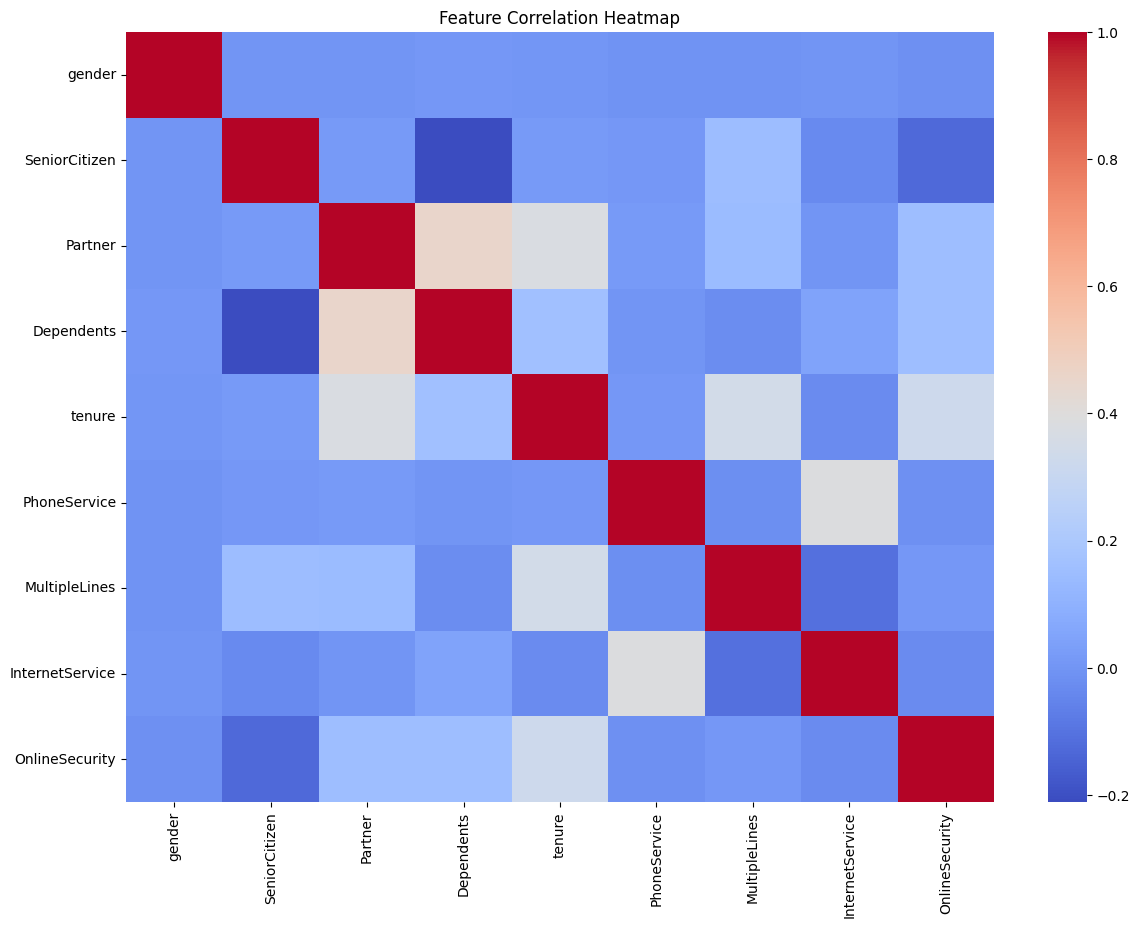


--- Training Models ---
Decision Tree Accuracy: 0.7736
Random Forest Accuracy: 0.7324
K-Nearest Neighbors (KNN) Accuracy: 0.7381
Logistic Regression Accuracy: 0.7899

Generating Confusion Matrices...


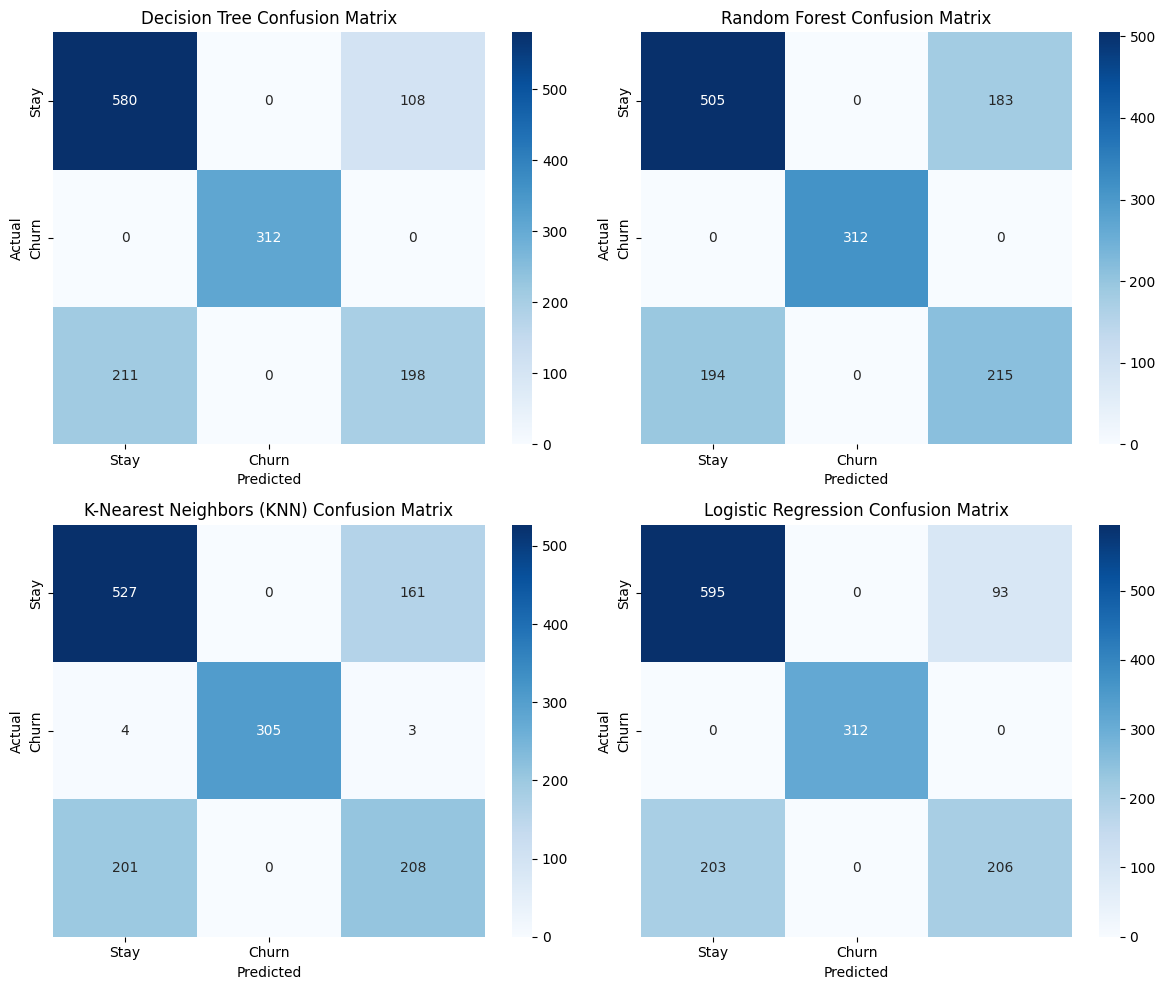


--- Detailed Classification Report: Random Forest ---
              precision    recall  f1-score   support

           0       0.72      0.73      0.73       688
           1       1.00      1.00      1.00       312
           2       0.54      0.53      0.53       409

    accuracy                           0.73      1409
   macro avg       0.75      0.75      0.75      1409
weighted avg       0.73      0.73      0.73      1409



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==========================================
# 1. LOAD DATA FROM COLAB LOCAL FILES
# ==========================================
# Ensure you have dragged your dataset into the Colab 'Files' tab
file_path = "/content/churn.csv"
print(f"Loading local dataset from {file_path}...")

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data with {len(df)} rows and {len(df.columns)} columns.")
except FileNotFoundError:
    print(f"Error: Could not find '{file_path}'. Please upload 'churn.csv' to the Files sidebar.")
    raise

# ==========================================
# 2. DATA PREPROCESSING
# ==========================================
print("\nCleaning and preprocessing data...")

# Drop ID column if it exists (adjust 'customerID' to your actual ID column name if different)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Convert any known string numeric columns to float (e.g., TotalCharges in Telco dataset)
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df.dropna(inplace=True)

# Encode categorical variables automatically
categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Assume the target column is named 'Churn' (adjust if yours is named differently, like 'target')
target_col = 'Churn' if 'Churn' in df.columns else df.columns[-1]
print(f"Using '{target_col}' as the target variable for predictions.")

X = df.drop(target_col, axis=1)
y = df[target_col]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (Critical for KNN and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. FEATURE CORRELATION HEATMAP
# ==========================================
print("\nGenerating Correlation Heatmap...")
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

# ==========================================
# 4. INITIALIZE AND TRAIN MODELS
# ==========================================
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000)
}

results = {}

print("\n--- Training Models ---")
for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    # Predict
    y_pred = model.predict(X_test_scaled)
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# ==========================================
# 5. CONFUSION MATRICES FOR ALL MODELS
# ==========================================
print("\nGenerating Confusion Matrices...")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ==========================================
# 6. DETAILED REPORT (Random Forest Example)
# ==========================================
print("\n--- Detailed Classification Report: Random Forest ---")
rf_pred = models["Random Forest"].predict(X_test_scaled)
print(classification_report(y_test, rf_pred))